In [30]:
import pandas as pd
import os
from pathlib import Path

In [31]:
def load_data(path: str) -> pd.DataFrame:
    """loads data from a csv file and returns a pandas DataFrame"""
    df = pd.read_csv(path)
    return df


def load_customers() -> pd.DataFrame:
    """loads customer data from the subject folder and returns a pandas DataFrame"""
    dfs = []
    base_path = Path.cwd()
    data_path = (base_path / "../subject/customer").resolve()

    if not data_path.exists():
        print(f"Directory not found: {data_path}")
        return

    for file in data_path.glob("*.csv"):
        dfs.append(pd.read_csv(file))
        
    contacts = pd.concat(dfs)
    contacts['event_time'] = pd.to_datetime(contacts['event_time'])
    return contacts


def load_items():
    """loads item data from the subject folder and returns a pandas DataFrame"""
    df = load_data("../subject/item/item.csv")
    return df


def merge_data(items, customers) -> pd.DataFrame:
    """merges the customer and item dataframes on the product_id column and returns a new DataFrame"""
    df = pd.merge(customers, items, on="product_id")
    return df


def remove_doubles(df: pd.DataFrame) -> pd.DataFrame:
    """
    removes rows from the DataFrame where the same 
    product_id, event_type, and event_time occur 
    within 1 second of each other
    """
    df = df.sort_values(by=['product_id', 'event_type', 'event_time'])
    time_diff = df.groupby(['product_id', 'event_type'])['event_time'].diff()
    df_cleaned = df[~(time_diff <= pd.Timedelta(seconds=1))]
    return df_cleaned

In [32]:
customers = load_customers()
customers = remove_doubles(customers)
items = load_items()
customers = merge_data(items, customers)

In [33]:
customers.head()

,event_time,event_type,product_id,price,user_id,user_session,category_id,category_code,brand
0,2022-10-01 12:11:11+00:00,view,3752,15.71,306131139,7a03835b-217e-4f6e-a5f8-11e5ae5652c6,1.487580e+18,NaN,cnd
1,2022-10-01 12:11:11+00:00,view,3752,15.71,306131139,7a03835b-217e-4f6e-a5f8-11e5ae5652c6,NaN,NaN,NaN
2,2022-10-10 11:21:17+00:00,view,3752,15.71,558771491,a780a267-3e66-4270-8091-084831a3f3d8,1.487580e+18,NaN,cnd
3,2022-10-10 11:21:17+00:00,view,3752,15.71,558771491,a780a267-3e66-4270-8091-084831a3f3d8,NaN,NaN,NaN
4,2022-10-11 13:16:44+00:00,view,3752,15.71,559168947,f622ed9d-68ca-436a-9a18-e1b96b6041fc,1.487580e+18,NaN,cnd


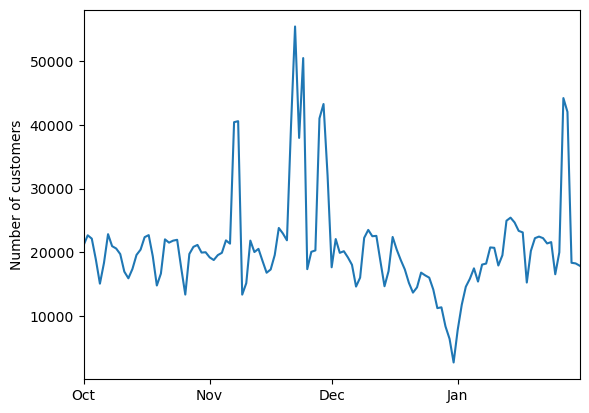

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

data = customers[(customers["event_type"] == "purchase")].copy()

daily_purchases = data.groupby(data["event_time"].dt.date).size()
plt.plot(daily_purchases.index, daily_purchases.values)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xlim(left=daily_purchases.index.min(), right=daily_purchases.index.max())

plt.ylabel("Number of customers")

plt.show()

/tmp/ipykernel_29037/3156434220.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_income = data.groupby(data["event_time"].dt.to_period("M"))["price"].sum() / 1000000


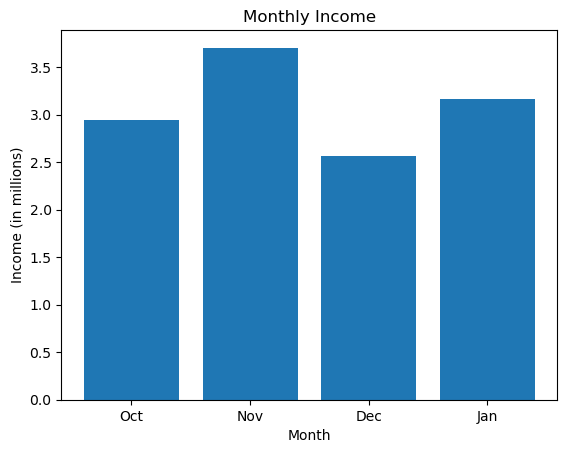

In [35]:
monthly_income = data.groupby(data["event_time"].dt.to_period("M"))["price"].sum() / 1000000

month_names = monthly_income.index.strftime('%b')
plt.bar(month_names, monthly_income.values)

plt.xlabel("Month")
plt.ylabel("Income (in millions)")
plt.title("Monthly Income")
plt.show()

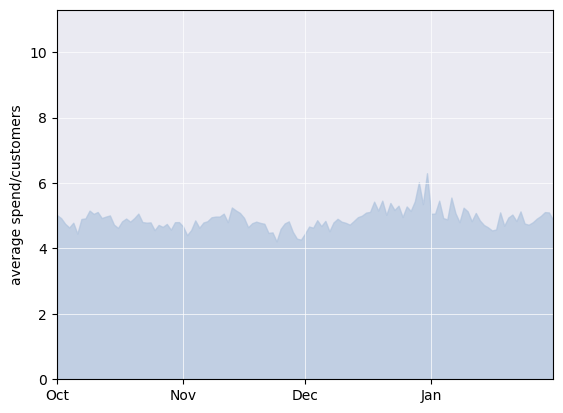

In [ ]:

daily_avg = data.groupby(data["event_time"].dt.date)["price"].mean()

plt.fill_between(daily_avg.index, daily_avg.values, color='lightsteelblue', alpha=0.7)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.xlim(daily_avg.index.min(), daily_avg.index.max())
plt.ylim(0, daily_avg.max() + 5) 

plt.ylabel("average spend/customers")
plt.xlabel("")
plt.grid(True, color='white', linestyle='-', linewidth=0.5)
ax.set_facecolor('#EAEAF2')

plt.show()